## Рекомендательная система для Steam

**Подход: Content-Based**

Мы решили использовать этот подход, потому что у нас нет данных о пользовательской активности и потому что на основе жанров и тегов можно легко объяснить пользователю, почему ему подходит определенная игра.

Наша система работает по принципу **item-to-item**: пользователь смотрит на конкретную игру, и мы рекомендуем ему похожие игры на основе их признаков.

Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

## Шаг 2. Загрузка и очистка данных

In [ ]:
df_raw = pd.read_csv('/content/steam.csv')
def clean_data(df):

    # 1. ОЧИСТКА
    df['developer'] = df['developer'].fillna('Unknown')
    df['publisher'] = df['publisher'].fillna('Unknown')

    # 2. НОВЫЕ ПРИЗНАКИ

    # release_year - год релиза игры (извлечён из release_date)
    df['release_year'] = df['release_date'].str[:4].astype(int)

    # rating_ratio - доля положительных отзывов у игры, посчитано через positive_ratings и negative_ratings
    df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
    df['rating_ratio'] = df['positive_ratings'] / (df['total_ratings'] + 1)

    def parse_owners(x):
        try:
            low, high = x.split('-')
            return (int(low.replace(',', '')) + int(high.replace(',', ''))) / 2
        except:
            return None

    # owners_mean - среднее количество обладателей игры, извлечено из диапазона в owners
    df['owners_mean'] = df['owners'].apply(parse_owners)


    # 3. БИНАРНЫЕ ПРИЗНАКИ (для One-Hot)

    def make_binary(df, col, prefix):
        mlb = MultiLabelBinarizer()
        binary = mlb.fit_transform(df[col].str.lower().str.split(';'))
        return pd.DataFrame(binary, columns=[f'{prefix}_{c}' for c in mlb.classes_])

    genres_df = make_binary(df, 'genres', 'genre')
    categories_df = make_binary(df, 'categories', 'cat')
    tags_df = make_binary(df, 'steamspy_tags', 'tag')
    platforms_df = make_binary(df, 'platforms', 'platform')

    # Убираем из тегов всё, что есть в других колонках
    cols_to_remove = set()
    cols_to_remove.update([col.replace('genre_', '') for col in genres_df.columns])
    cols_to_remove.update([col.replace('cat_', '') for col in categories_df.columns])
    cols_to_remove.update([col.replace('platform_', '') for col in platforms_df.columns])
    tags_clean = tags_df.drop(
        columns=[f'tag_{val}' for val in cols_to_remove if f'tag_{val}' in tags_df.columns],
        errors='ignore'
    )


    # 4. ТЕКСТОВЫЕ ПРИЗНАКИ (для TF-IDF)

    df['genres_text'] = df['genres'].str.lower().str.replace(';', ' ', regex=False)
    df['categories_text'] = df['categories'].str.lower().str.replace(';', ' ', regex=False)
    df['platforms_text'] = df['platforms'].str.lower().str.replace(';', ' ', regex=False)

    # Очищаем теги от жанров и категорий для текста
    all_genres = set()
    for val in df['genres'].dropna():
        if isinstance(val, str):
            for v in val.split(';'):
                all_genres.add(v.strip().lower())

    all_categories = set()
    for val in df['categories'].dropna():
        if isinstance(val, str):
            for v in val.split(';'):
                all_categories.add(v.strip().lower())

    def clean_tags_text(tags_str):
        if not isinstance(tags_str, str):
            return ''
        tags = [t.strip().lower() for t in tags_str.split(';')]
        filtered = [t for t in tags if t not in all_genres and t not in all_categories]
        return ' '.join(filtered)

    df['tags_text_clean'] = df['steamspy_tags'].apply(clean_tags_text)

    # 5. КОДИРОВАНИЕ developer
    le = LabelEncoder()
    df['developer_encoded'] = le.fit_transform(df['developer'])

    # 6. ОБЪЕДИНЯЕМ One-Hot признаки в основной DataFrame
    df_onehot = pd.concat([genres_df, categories_df, tags_clean, platforms_df], axis=1)
    df = pd.concat([df, df_onehot], axis=1)

    return df

df = clean_data(df_raw.copy())

df.head(3)

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,tag_werewolves,tag_western,tag_word game,tag_world war i,tag_world war ii,tag_wrestling,tag_zombies,platform_linux,platform_mac,platform_windows
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,0,0,0,0,0,0,0,1,1,1
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,0,0,0,0,0,0,0,1,1,1
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,...,0,0,0,0,1,0,0,1,1,1


## Отбор признаков для модели

Мы используем два типа признаков:
- **Бинарные** (0/1): жанры, категории, теги, платформы — уже готовы, нормализация не нужна
- **Числовые**: `rating_ratio`, `positive_ratings`, `negative_ratings`, `price`, `developer_encoded` — нужно нормализовать

In [ ]:
binary_cols = [col for col in df.columns if col.startswith(('genre_', 'cat_', 'tag_', 'platform_'))]
numeric_cols = ['rating_ratio', 'positive_ratings', 'negative_ratings', 'price', 'developer_encoded']

print(f'Бинарных признаков:  {len(binary_cols)}')
print(f'Числовых признаков:  {len(numeric_cols)}')
print(f'Итого признаков:     {len(binary_cols) + len(numeric_cols)}')

Бинарных признаков:  370
Числовых признаков:  5
Итого признаков:     375


In [ ]:
#Нормализуем числовые признаки вручную
scaler_pre = StandardScaler()
numeric_scaled = scaler_pre.fit_transform(df[numeric_cols])
df_numeric = pd.DataFrame(numeric_scaled, columns=numeric_cols, index=df.index)

# Собираем итоговую матрицу: числовые (нормализованные) + бинарные
feature_matrix = pd.concat([df_numeric, df[binary_cols]], axis=1)

print(f'Размер матрицы признаков до SVD: {feature_matrix.shape}')
print(f'  → {feature_matrix.shape[0]} игр × {feature_matrix.shape[1]} признаков')

Размер матрицы признаков до SVD: (27075, 375)
  → 27075 игр × 375 признаков


##Подбор числа компонент SVD

Мы выбрали SVD, потому что он помогает сжимать количество признаков, удалять шум и улучшать косинусное сходство.

Главный гиперпараметр SVD — **n_components**:

*  Слишком мало → потеряем важную информацию  
*  Слишком много → не избавимся от шума, потеряем смысл сжатия

Смотрим на **объяснённую дисперсию** — сколько информации сохраняется при разном числе компонент.

In [ ]:
# Обучаем SVD с максимальным числом компонент, чтобы посмотреть на дисперсию
svd_analysis = TruncatedSVD(n_components=200, random_state=42)
svd_analysis.fit(feature_matrix.values)

cumvar = np.cumsum(svd_analysis.explained_variance_ratio_)

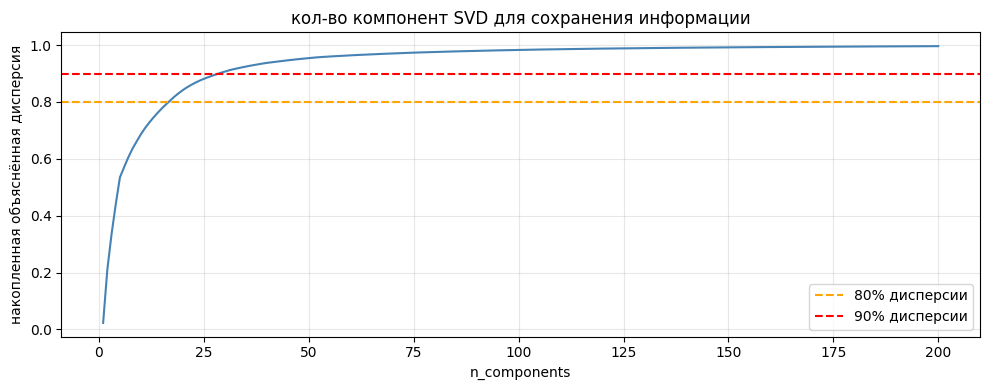

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, color='steelblue')
plt.axhline(y=0.80, color='orange', linestyle='--', label='80% дисперсии')
plt.axhline(y=0.90, color='red',    linestyle='--', label='90% дисперсии')
plt.xlabel('n_components')
plt.ylabel('накопленная объяснённая дисперсия')
plt.title('кол-во компонент SVD для сохранения информации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Находим минимальное число компонент для порогов 80% и 90%
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
print(f'Для 80% дисперсии нужно компонент: {n_80}')
print(f'Для 90% дисперсии нужно компонент: {n_90}')

Для 80% дисперсии нужно компонент: 17
Для 90% дисперсии нужно компонент: 29


##Обучение модели TruncatedSVD


In [ ]:
N_COMPONENTS = n_90

model_pipeline = Pipeline([
    #нормализуем всю матрицу перед SVD
    ('scaler', StandardScaler()),
    #обучение
    ('svd', TruncatedSVD(n_components=N_COMPONENTS, random_state=42))
])

game_embeddings = model_pipeline.fit_transform(feature_matrix.values)

print(f'Матрица эмбеддингов игр: {game_embeddings.shape}')
print(f'  → {game_embeddings.shape[0]} игр × {game_embeddings.shape[1]} латентных факторов')
print(f'\nСжатие: {feature_matrix.shape[1]} признаков → {N_COMPONENTS} латентных факторов')

total_variance = model_pipeline.named_steps['svd'].explained_variance_ratio_.sum()
print(f'Сохранено дисперсии: {total_variance:.1%}')

Матрица эмбеддингов игр: (27075, 29)
  → 27075 игр × 29 латентных факторов

Сжатие: 375 признаков → 29 латентных факторов
Сохранено дисперсии: 14.4%


##Построение матрицы косинусного сходства


In [ ]:
similarity_matrix = cosine_similarity(game_embeddings)

print(f'Матрица сходства: {similarity_matrix.shape}')

Матрица сходства: (27075, 27075)


In [ ]:
#проверка - ожидается 1.0
print(f'{np.diag(similarity_matrix).mean():.4f}')

1.0000


##Функция рекомендаций

Возвращает топ-N рекомендаций для заданной игры на основе SVD-эмбеддингов.

Параметры:

* game_name: str - название игры, которую просматривает пользователь;
* df: полный датафрейм с данными об играх;
* similarity_matrix - матрица косинусного сходства;
* n (=5): количество рекомендаций, мы выбрали пять, так как это кажется оптимальным числом рекомендаций для пользователя, а также позволит нам эмпирически оцень качество рекомендаций.


In [ ]:
def get_recommendations(game_name, df, similarity_matrix, n=5):
    #Поиск игры
    matches = df[df['name'].str.lower() == game_name.lower()]

    if matches.empty:
        #частичное совпадение, если точного нет
        matches = df[df['name'].str.lower().str.contains(game_name.lower(), na=False)]
        if matches.empty:
            print(f'игра "{game_name}" не найдена в датасете')
            return None
        print(f'используем: "{matches.iloc[0]["name"]}"')

    game_idx = matches.index[0]

    sim_scores = list(enumerate(similarity_matrix[game_idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != game_idx]

    top_n = sim_scores[:n]

    top_indices = [i for i, _ in top_n]
    top_scores  = [s for _, s in top_n]

    result = df.loc[top_indices, ['name', 'genres', 'categories', 'platforms', 'rating_ratio', 'price']].copy()
    result['similarity_score'] = [round(s, 4) for s in top_scores]
    result['rating_ratio'] = result['rating_ratio'].round(2)

    return result.reset_index(drop=True)

## смотрим на работу модели

In [ ]:
def show_recommendations(game_name, df, similarity_matrix, n=5):

    print('=' * 65)
    print(f'👤 Пользователь просматривает игру: "{game_name}"')
    print('=' * 65)

    recommendations = get_recommendations(game_name, df, similarity_matrix, n=n)
    if recommendations is None:
        return

    print(f'🎮 Вам могут понравиться эти {n} игр:\n')

    for i, row in recommendations.iterrows():
        print(f'  {i+1}. {row["name"]}')
        print(f'🏷️  Жанр: {row["genres"]}')
        print(f'📂 Категории: {row["categories"]}')
        print(f'💻 Платформы: {row["platforms"]}')
        rating_pct = int(row['rating_ratio'] * 100)
        print(f'⭐ Рейтинг: {rating_pct}% положительных отзывов')
        price_str = 'Бесплатно' if row['price'] == 0 else f'${row["price"]:.2f}'
        print(f'💸 Цена: {price_str}')
        print(f'🔗 Сходство: {row["similarity_score"]:.4f}')
        print()

    print('=' * 65)

show_recommendations('Stardew Valley', df, similarity_matrix, n=5)

👤 Пользователь просматривает игру: "Fortnite"
игра "Fortnite" не найдена в датасете


## Визуализация пространства SVD

Посмотрим, как SVD расположил игры в пространстве латентных факторов. Возьмём первые две компоненты для визуализации на плоскости.

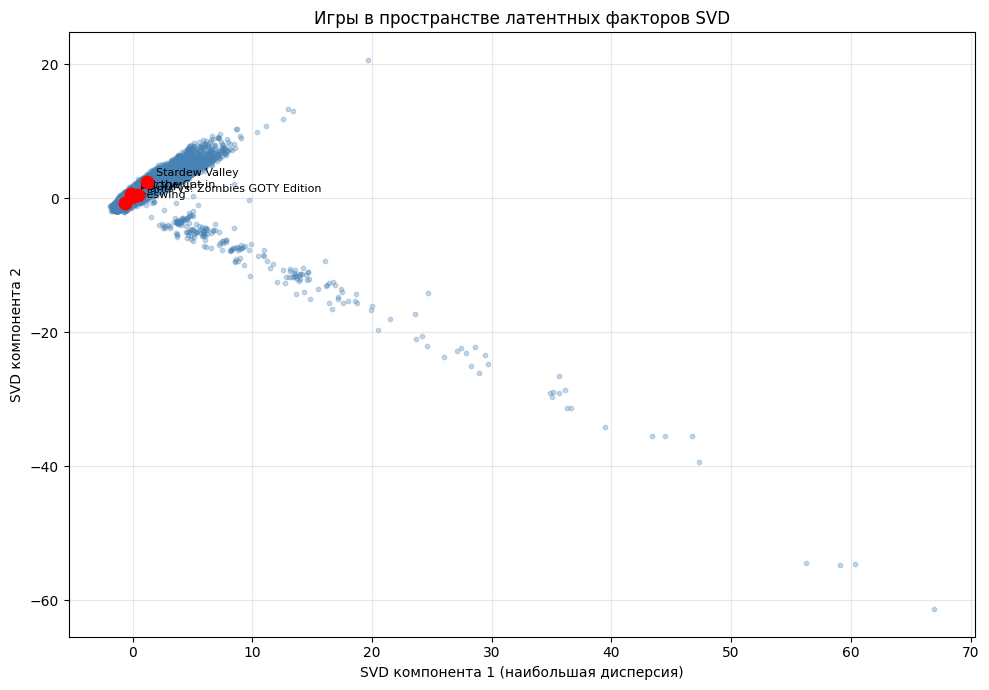

In [ ]:
x = game_embeddings[:, 0]
y = game_embeddings[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.3, s=10, color='steelblue')

#подсвечиваем несколько игр для ориентира
highlight_games = ['DOOM II', 'Beeswing', 'Stardew Valley', 'Plants vs. Zombies GOTY Edition', 'Let the Cat in']
for game in highlight_games:
    match = df[df['name'].str.lower() == game.lower()]
    if not match.empty:
        idx = match.index[0]
        plt.scatter(x[idx], y[idx], s=80, zorder=5, color='red')
        plt.annotate(
            game,
            (x[idx], y[idx]),
            textcoords='offset points', xytext=(6, 4), fontsize=8
        )

plt.xlabel('SVD компонента 1 (наибольшая дисперсия)')
plt.ylabel('SVD компонента 2')
plt.title('Игры в пространстве латентных факторов SVD')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Сохранение модели

In [ ]:
import joblib

In [ ]:
joblib.dump(model_pipeline, 'recsys_pipeline.pkl')

np.save('game_embeddings.npy', game_embeddings)

print('Модель сохранена: recsys_pipeline.pkl')
print('Эмбеддинги сохранены: game_embeddings.npy')

Модель сохранена: recsys_pipeline.pkl
Эмбеддинги сохранены: game_embeddings.npy
